In [1]:
import os, pandas
import omnipath, mygene
import matplotlib.pyplot

In [2]:
confidence_levels = ["A", 'B', 'C'] # A and B require both binding and co-expression, C is just binding without coexpression. D is presence of the motif without chipseq evidence

In [3]:
### get dorothea

dorothea = omnipath.interactions.Dorothea.get(
    organism="human",
    dorothea_levels=confidence_levels
)

dorothea = pandas.DataFrame(dorothea)
print(dorothea.shape)
# abc is 32629 elements
# nothing is 15k!!!!
# a is 6k
# ab is 15k
# abc is 32k
# abcde is 278k
# abcd is
dorothea

(32629, 15)


,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped
0,P01106,O14746,False,True,False,True,True,False,7,,DoRothEA;HTRIdb_DoRothEA;KEGG_DoRothEA;RegNetw...,7,1,1,
1,P84022,P05412,False,True,False,True,True,False,6,DoRothEA:10022869,DoRothEA;RegNetwork_DoRothEA;TFactS_DoRothEA;T...,5,1,1,10022869
2,Q13485,P05412,False,True,False,True,True,False,6,DoRothEA:10022869,DoRothEA;RegNetwork_DoRothEA;TFactS_DoRothEA;T...,5,1,1,10022869
3,P08047,P04075,False,True,False,True,True,False,7,DoRothEA:8524331,DoRothEA;ORegAnno_DoRothEA;RegNetwork_DoRothEA...,6,1,1,8524331
4,P04637,P08069,False,False,True,True,False,True,6,,DoRothEA;PAZAR_DoRothEA;ReMap_DoRothEA;RegNetw...,6,1,1,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32624,Q5HY98,Q9Y4F3,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,
32625,P51522,O60494,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,
32626,P51522,Q15365,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,
32627,P51522,Q7KZF4,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,


In [4]:
### translate dorothea

mg = mygene.MyGeneInfo()

# collect unique UniProt IDs
ids = pandas.unique(dorothea[["source", "target"]].values.ravel())

# map to gene symbols
res = mg.querymany(
    ids,
    scopes="uniprot",
    fields="symbol",
    species="human",
    verbose=False
)

u2g = {r["query"]: r["symbol"] for r in res if not r.get("notfound", False)}

# add symbols
dorothea["source_symbol"] = dorothea["source"].map(u2g)
dorothea["target_symbol"] = dorothea["target"].map(u2g)

# QC
n_total = len(dorothea)
n_both = dorothea["source_symbol"].notna().sum() & dorothea["target_symbol"].notna().sum()

print("edges:", n_total)
print("edges with both symbols:", (dorothea["source_symbol"].notna() & dorothea["target_symbol"].notna()).sum())
print("fraction recovered:", (dorothea["source_symbol"].notna() & dorothea["target_symbol"].notna()).mean())

dorothea

edges: 32629
edges with both symbols: 32469
fraction recovered: 0.9950963866499126


,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped,source_symbol,target_symbol
0,P01106,O14746,False,True,False,True,True,False,7,,DoRothEA;HTRIdb_DoRothEA;KEGG_DoRothEA;RegNetw...,7,1,1,,MYC,TERT
1,P84022,P05412,False,True,False,True,True,False,6,DoRothEA:10022869,DoRothEA;RegNetwork_DoRothEA;TFactS_DoRothEA;T...,5,1,1,10022869,SMAD3,JUN
2,Q13485,P05412,False,True,False,True,True,False,6,DoRothEA:10022869,DoRothEA;RegNetwork_DoRothEA;TFactS_DoRothEA;T...,5,1,1,10022869,SMAD4,JUN
3,P08047,P04075,False,True,False,True,True,False,7,DoRothEA:8524331,DoRothEA;ORegAnno_DoRothEA;RegNetwork_DoRothEA...,6,1,1,8524331,SP1,ALDOA
4,P04637,P08069,False,False,True,True,False,True,6,,DoRothEA;PAZAR_DoRothEA;ReMap_DoRothEA;RegNetw...,6,1,1,,TP53,IGF1R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32624,Q5HY98,Q9Y4F3,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,,ZNF766,MARF1
32625,P51522,O60494,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,,ZNF83,CUBN
32626,P51522,Q15365,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,,ZNF83,PCBP1
32627,P51522,Q7KZF4,True,False,False,False,True,True,3,,ARACNe-GTEx_DoRothEA;DoRothEA;ReMap_DoRothEA,3,1,1,,ZNF83,SND1


In [5]:
### find MITF target genes

mitf_regulon = dorothea[dorothea["source_symbol"] == 'MITF']
print("MITF regulon edges:", mitf_regulon.shape[0])

mitf_regulon = mitf_regulon.drop_duplicates(subset=["source_symbol", "target_symbol"])
print("MITF regulon edges:", mitf_regulon.shape[0])


sort_cols = [
    "n_sources",
    "curation_effort",
    "n_primary_sources",
    "n_references"
]

# keep only columns that actually exist (defensive)
sort_cols = [c for c in sort_cols if c in mitf_regulon.columns]

mitf_regulon_sorted = (
    mitf_regulon
    .sort_values(by=sort_cols, ascending=[False] * len(sort_cols))
    .reset_index(drop=True)
)

known_targets = set(mitf_regulon_sorted['target_symbol'])

mitf_regulon_sorted.head(20)

MITF regulon edges: 674
MITF regulon edges: 666


,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped,source_symbol,target_symbol
0,O75030,P40126,False,True,False,True,True,False,6,,DoRothEA;KEGG_DoRothEA;PAZAR_DoRothEA;ReMap_Do...,6,1,1,,MITF,DCT
1,O75030,Q15555,True,False,False,False,True,True,6,,ARACNe-GTEx_DoRothEA;DoRothEA;HOCOMOCO_DoRothE...,6,1,1,,MITF,MAPRE2
2,O75030,P27695,False,True,False,True,True,False,6,DoRothEA:1999537,DoRothEA;HOCOMOCO_DoRothEA;JASPAR_DoRothEA;PAZ...,5,1,1,1999537,MITF,APEX1
3,O75030,P14679,False,True,False,True,True,False,5,,DoRothEA;KEGG_DoRothEA;PAZAR_DoRothEA;TFactS_D...,5,1,1,,MITF,TYR
4,O75030,P10721,False,True,False,True,True,False,5,,DoRothEA;PAZAR_DoRothEA;ReMap_DoRothEA;TFactS_...,5,1,1,,MITF,KIT
5,O75030,P17643,False,True,False,True,True,False,5,,DoRothEA;KEGG_DoRothEA;PAZAR_DoRothEA;TFactS_D...,5,1,1,,MITF,TYRP1
6,O75030,P08581,False,True,False,True,True,False,5,,DoRothEA;PAZAR_DoRothEA;ReMap_DoRothEA;TFactS_...,5,1,1,,MITF,MET
7,O75030,Q96CA5,False,True,False,True,True,False,5,,DoRothEA;HTRIdb_DoRothEA;PAZAR_DoRothEA;TFactS...,5,1,1,,MITF,BIRC7
8,O75030,Q14956,False,True,False,True,True,False,5,,ARACNe-GTEx_DoRothEA;DoRothEA;PAZAR_DoRothEA;T...,5,1,1,,MITF,GPNMB
9,O75030,P56377,True,False,False,False,True,True,5,,ARACNe-GTEx_DoRothEA;DoRothEA;HOCOMOCO_DoRothE...,5,1,1,,MITF,AP1S2


In [6]:
mitf_regulon_sorted[mitf_regulon_sorted['target_symbol'] == 'MITF']

,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped,source_symbol,target_symbol


In [7]:
def metrics(known, predicted):
    known = set(known)
    predicted = set(predicted)

    tp = len(known & predicted)
    fp = len(predicted - known)
    fn = len(known - predicted)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0

    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    f2 = (5 * precision * recall / (4 * precision + recall)) if (4 * precision + recall) else 0.0

    jaccard = tp / len(known | predicted) if (known | predicted) else 0.0

    print(f2)
    print()

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "F2": f2,
        "jaccard": jaccard,
        "n_known": len(known),
        "n_predicted": len(predicted),
    }

In [8]:
base_dir = "/Users/adrian/research/bmcbf/004_keilir/results/04_necio_f2_score/"

rows = []

for fname in sorted(os.listdir(base_dir)):
    if not fname.endswith(".txt"):
        continue
    if ".genes.multi." not in fname:
        continue  # skip anything else

    # Example: black.a.genes.multi.10kb.txt
    stem = fname[:-4]
    parts = stem.split(".")
    if len(parts) < 5:
        continue

    color = parts[0]
    condition = parts[1]
    window = parts[-1]

    print(color, condition, window)

    path = os.path.join(base_dir, fname)
    df = pandas.read_csv(path, sep="\t", header=None)

    identified = set(df.iloc[:, 0].dropna().astype(str))
    identified = {g for g in identified if g != "" and g.lower() != "nan"}

    res = metrics(known_targets, identified)
    

    rows.append({
        "file": fname,
        "color": color,
        "condition": condition,
        "window": window,
        **res,
    })

results_df = pandas.DataFrame(rows)

# Optional: enforce a logical window order
window_order = ["c150b", "c300b", "c500b", "s500b", "c1kb", "s1kb", "2kb", "5kb", "10kb", "25kb", "50kb"]
results_df["window"] = pandas.Categorical(results_df["window"], categories=window_order, ordered=True)

results_df.sort_values(["color", "condition", "window"])
results_df

black a 10kb
0.08850238571648453

black a 25kb
0.09352605368638407

black a 2kb
0.09229789942711648

black a 50kb
0.0993157679738562

black a 5kb
0.09182119501926006

black a c150b
0.09519177320733742

black a c1kb
0.09322360807509322

black a c300b
0.0963509635096351

black a c500b
0.09491525423728814

black a s1kb
0.09610675808031341

black a s500b
0.09530791788856306

black m 10kb
0.08979523329976502

black m 25kb
0.09537741369221767

black m 2kb
0.08006463934185397

black m 50kb
0.09620218454366802

black m 5kb
0.08520228671943711

black m c150b
0.061993323795898905

black m c1kb
0.07345439706182412

black m c300b
0.06336405529953916

black m c500b
0.06524184476940383

black m s1kb
0.07778410168848417

black m s500b
0.06926121372031663

gold a 10kb
0.08856372737774355

gold a 25kb
0.09330739772658198

gold a 2kb
0.09236649325830769

gold a 50kb
0.09888593622240391

gold a 5kb
0.09192000717424445

gold a c150b
0.09521823742007228

gold a c1kb
0.09324758842443731

gold a c300b
0.0963

,file,color,condition,window,tp,fp,fn,precision,recall,F1,F2,jaccard,n_known,n_predicted
0,black.a.genes.multi.10kb.txt,black,a,10kb,230,10100,436,0.022265,0.345345,0.041833,0.088502,0.021364,666,10330
1,black.a.genes.multi.25kb.txt,black,a,25kb,308,13494,358,0.022316,0.462462,0.042577,0.093526,0.021751,666,13802
2,black.a.genes.multi.2kb.txt,black,a,2kb,174,6588,492,0.025732,0.261261,0.046850,0.092298,0.023987,666,6762
3,black.a.genes.multi.50kb.txt,black,a,50kb,389,16531,277,0.022991,0.584084,0.044240,0.099316,0.022620,666,16920
4,black.a.genes.multi.5kb.txt,black,a,5kb,205,8294,461,0.024120,0.307808,0.044735,0.091821,0.022879,666,8499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,purple.m.genes.multi.c1kb.txt,purple,m,c1kb,17,675,649,0.024566,0.025526,0.025037,0.025328,0.012677,666,692
84,purple.m.genes.multi.c300b.txt,purple,m,c300b,12,487,654,0.024048,0.018018,0.020601,0.018969,0.010408,666,499
85,purple.m.genes.multi.c500b.txt,purple,m,c500b,14,533,652,0.025594,0.021021,0.023083,0.021800,0.011676,666,547
86,purple.m.genes.multi.s1kb.txt,purple,m,s1kb,22,783,644,0.027329,0.033033,0.029912,0.031709,0.015183,666,805


In [9]:
print(min(results_df['F2']))
print(max(results_df['F2']))

0.0189693329117926
0.0993157679738562


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_4958/3597218838.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(
/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_4958/3597218838.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(
/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_4958/3597218838.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(
/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipy

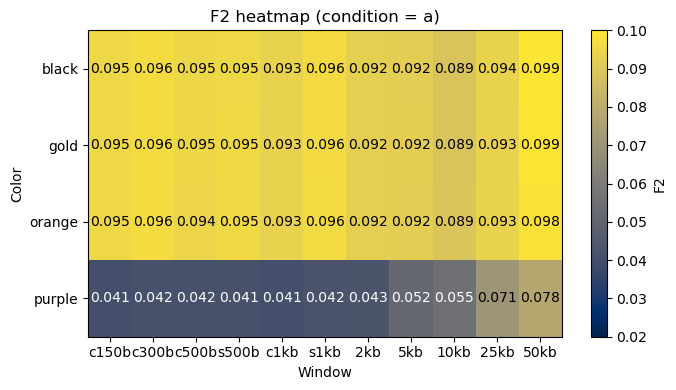

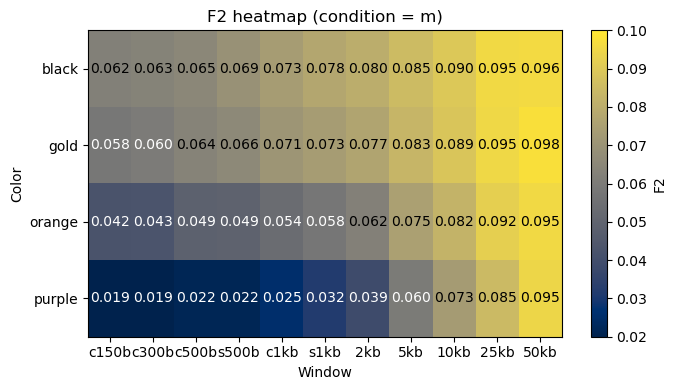

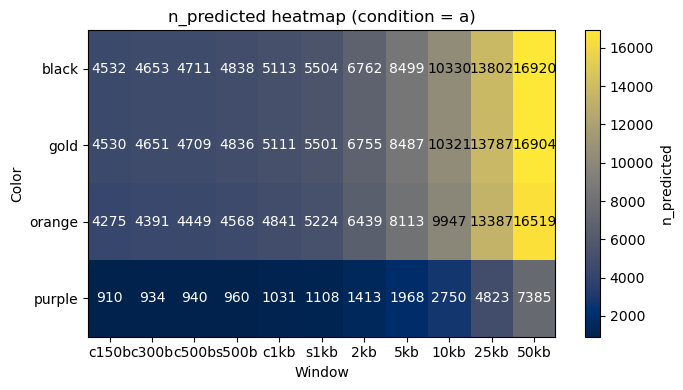

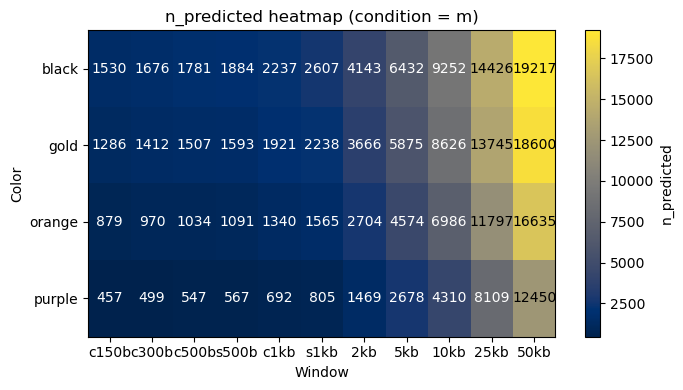

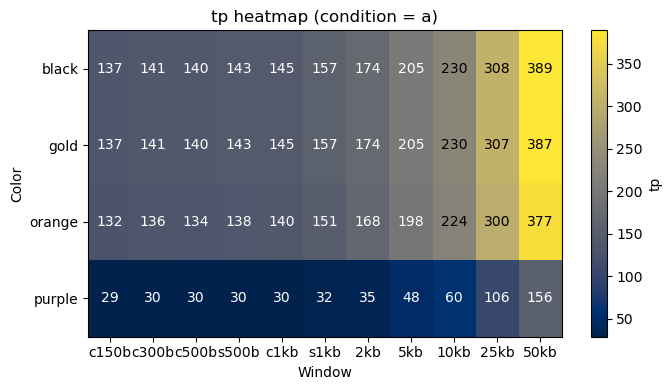

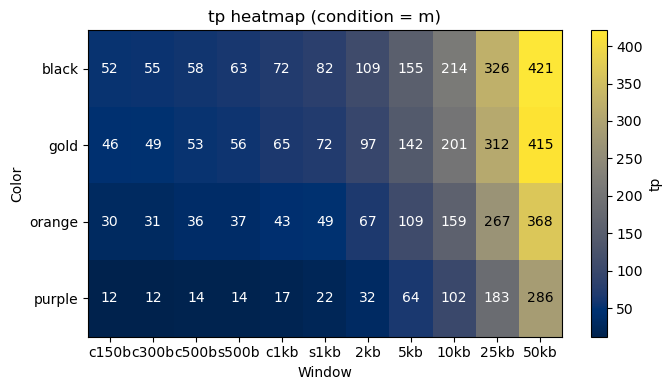

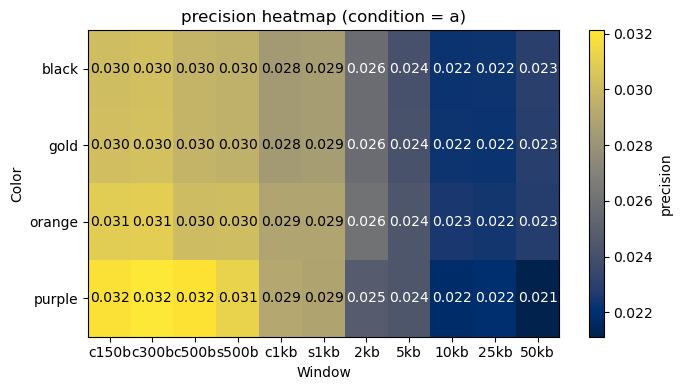

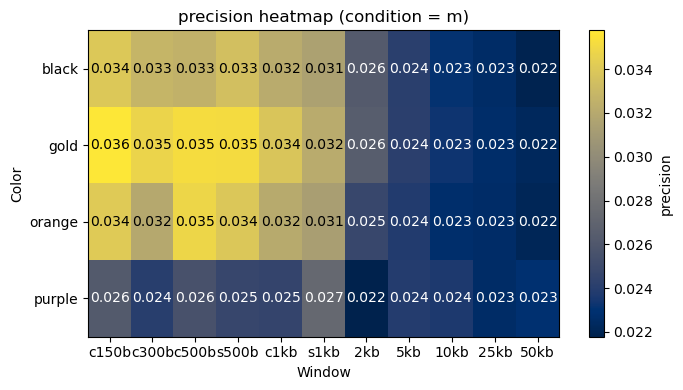

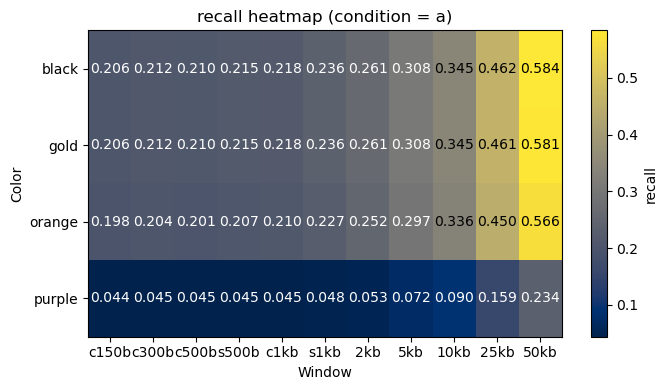

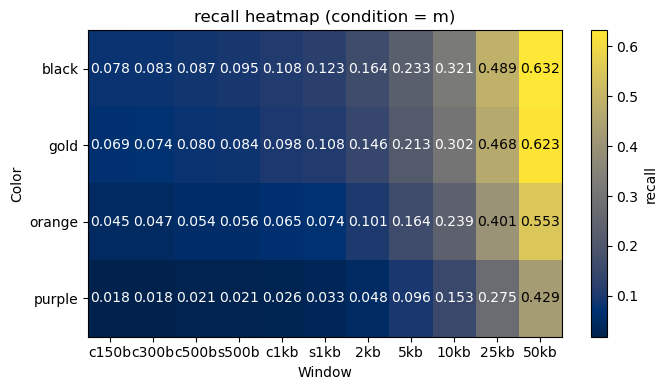

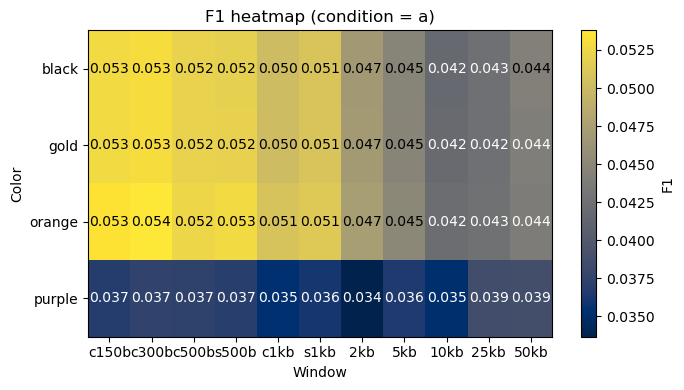

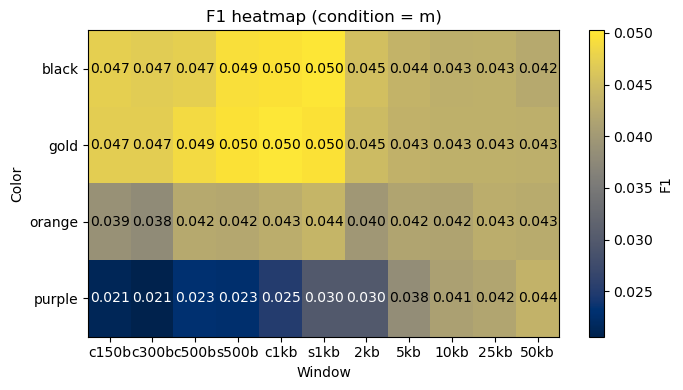

In [10]:
def plot_metric_heatmap(results_df, condition_value, metric, fmt=None):
    sub = results_df[results_df["condition"] == condition_value].copy()

    pivot = sub.pivot_table(
        index="color",
        columns="window",
        values=metric,
        aggfunc="mean"
    )

    # Ensure consistent column order
    pivot = pivot.reindex(columns=[w for w in window_order if w in pivot.columns])

    fig = matplotlib.pyplot.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)


    if metric == 'F2':
        im = ax.imshow(pivot.values, aspect="auto", cmap="cividis", vmin=0.02, vmax=0.1)
    else:
        im = ax.imshow(pivot.values, aspect="auto", cmap="cividis")

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(list(pivot.columns), rotation=0)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(list(pivot.index))

    ax.set_title(f"{metric} heatmap (condition = {condition_value})")
    ax.set_xlabel("Window")
    ax.set_ylabel("Color")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(metric)

    # Choose annotation format
    if fmt is None:
        if metric in ["tp", "fp", "fn", "n_known", "n_predicted", "n_genes", "intersect"]:
            fmt = "{:d}"
        else:
            fmt = "{:.3f}"

    # Annotate values with adaptive text color
    norm = im.norm
    cmap = im.cmap
    
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pandas.notna(v):
                rgba = cmap(norm(v))
                # perceived luminance (ITU-R BT.709)
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                text_color = "black" if luminance > 0.5 else "white"
    
                if fmt == "{:d}":
                    label = fmt.format(int(round(v)))
                else:
                    label = fmt.format(float(v))
    
                ax.text(j, i, label, ha="center", va="center", color=text_color)

    fig.tight_layout()
    return fig, ax


metrics_to_plot = ["F2", "n_predicted", "tp", "precision", "recall", 'F1']

for metric in metrics_to_plot:
    plot_metric_heatmap(results_df, "a", metric)
    plot_metric_heatmap(results_df, "m", metric)

matplotlib.pyplot.show()
